# Modelo de Risco de Aumento de Defasagem — PEDE / Passos Mágicos

**Objetivo:** prever a probabilidade de um aluno **aumentar sua defasagem escolar no ano seguinte**, para permitir intervenção preventiva.

**Alvo:** `aumento_defasagem = 1` se `defasagem(t+1) < defasagem(t)` — calculado sobre `defasagem` bruta (D = Fase Efetiva − Fase Ideal), não sobre `IAN`, que é uma transformação com perda dela (só 3 faixas: 10/5/2,5).

**Validação:** split aleatório **agrupado por RA** — um mesmo aluno nunca aparece em treino e teste ao mesmo tempo.

**Saída:** probabilidade contínua + limiar otimizado, ambos salvos em `.joblib` para uso no Streamlit.

> Contexto completo das decisões, comparação de modelos descartados e guia de interpretação: ver `03_Base_Conhecimento_Modelo.md`.


## 1. Setup

In [1]:
import re, warnings, unicodedata, datetime
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
print("Ambiente pronto.")


Ambiente pronto.


## 2. Carga e padronização

Padronização idêntica à da EDA: unifica nomes de coluna entre as 3 abas, corrige a `Idade` de 2023 (399 valores digitados como data) e converte `Fase` em ordem numérica.


In [2]:
EXCEL_FILE = Path.cwd() / "BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx"
raw_sheets = pd.read_excel(EXCEL_FILE, sheet_name=None, engine="openpyxl")


def norm_col(v):
    t = unicodedata.normalize("NFKD", str(v).strip())
    t = "".join(c for c in t if not unicodedata.combining(c))
    return re.sub(r"[^a-zA-Z0-9]+", "_", t).strip("_").lower()


def first_existing(m, *cands):
    for c in cands:
        if c in m:
            return m[c]
    return None


def build_column_map(columns, year):
    m = {norm_col(c): c for c in columns}
    yy = str(year)[-2:]
    return {
        "ra": first_existing(m, "ra"),
        "fase_raw": first_existing(m, "fase"),
        "idade": first_existing(m, "idade", "idade_22"),
        "genero": first_existing(m, "genero"),
        "ano_ingresso": first_existing(m, "ano_ingresso"),
        "instituicao": first_existing(m, "instituicao_de_ensino"),
        "inde": first_existing(m, f"inde_{year}", f"inde_{yy}"),
        "pedra": first_existing(m, f"pedra_{year}", f"pedra_{yy}"),
        "iaa": first_existing(m, "iaa"), "ieg": first_existing(m, "ieg"),
        "ips": first_existing(m, "ips"), "ida": first_existing(m, "ida"),
        "ipv": first_existing(m, "ipv"), "ian": first_existing(m, "ian"),
        "defasagem": first_existing(m, "defasagem", "defas"),
    }


def canonical_pedra(v):
    if pd.isna(v):
        return np.nan
    b = unicodedata.normalize("NFKD", str(v).strip())
    b = "".join(c for c in b if not unicodedata.combining(c)).lower()
    return {"quartzo": "Quartzo", "agata": "Ágata", "ametista": "Ametista",
            "topazio": "Topázio", "incluir": "INCLUIR"}.get(b, str(v).strip())


def parse_fase_ordem(v):
    if pd.isna(v):
        return np.nan
    t = str(v).strip().upper()
    if t in {"ALFA", "FASE ALFA"}:
        return 0
    mm = re.search(r"(\d+)", t)
    return int(mm.group(1)) if mm else np.nan


def fix_idade(v):
    return v.day if isinstance(v, (datetime.datetime, pd.Timestamp)) else v


frames = []
for sheet, df in raw_sheets.items():
    ym = re.search(r"(20\d{2})", sheet)
    if not ym:
        continue
    year = int(ym.group(1))
    cmap = build_column_map(df.columns, year)
    out = pd.DataFrame(index=df.index)
    out["ano"] = year
    for new, orig in cmap.items():
        out[new] = df[orig] if orig else np.nan
    out["idade"] = out["idade"].map(fix_idade)
    frames.append(out)

base = pd.concat(frames, ignore_index=True)
for c in ["idade", "ano_ingresso", "inde", "iaa", "ieg", "ips", "ida", "ipv", "ian", "defasagem"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")
base["pedra"] = base["pedra"].map(canonical_pedra)
base["fase_ordem"] = base["fase_raw"].map(parse_fase_ordem)
base["gap_iaa_ida"] = base["iaa"] - base["ida"]

print(f"Base padronizada: {base.shape[0]:,} linhas")


Base padronizada: 3,030 linhas


## 3. Painel temporal e definição do alvo

Cada linha = um aluno em um ano de referência (t), com o alvo vindo do ano seguinte (t+1) do mesmo `RA`.


In [3]:
panel = base.sort_values(["ra", "ano"]).copy()
panel["defasagem_next"] = panel.groupby("ra")["defasagem"].shift(-1)
panel["ano_next"] = panel.groupby("ra")["ano"].shift(-1)

pv = panel[
    panel["ano_next"].eq(panel["ano"] + 1)
    & panel["defasagem_next"].notna()
    & panel["defasagem"].notna()
].copy().reset_index(drop=True)

pv["aumento_defasagem"] = (pv["defasagem_next"] < pv["defasagem"]).astype(int)

display(Markdown(f'''
**Painel:** {len(pv):,} pares aluno-ano | **{pv['ra'].nunique():,} alunos únicos**
**Taxa de eventos positivos:** {pv['aumento_defasagem'].mean()*100:.1f}%
'''))
display(pv.groupby("ano").agg(pares=("ra", "count"), taxa_positiva=("aumento_defasagem", "mean")).round(3))



**Painel:** 1,365 pares aluno-ano | **897 alunos únicos**
**Taxa de eventos positivos:** 17.3%


,pares,taxa_positiva
ano,,
2022,600,0.1730
2023,765,0.1730


## 4. Features

**Excluídas de propósito:** `ian` (redundante — é função determinística de `defasagem`), `ipp` (100% nula em 2022) e `ano` (não generaliza para anos futuros).


In [4]:
FEATURES_NUM = ["defasagem", "fase_ordem", "idade", "ano_ingresso",
                "ida", "ieg", "iaa", "ips", "ipv", "inde"]
FEATURES_NOM = ["genero", "instituicao"]
FEATURES_ORD = ["pedra"]
ORDEM_PEDRA = [["Quartzo", "Ágata", "Ametista", "Topázio"]]
FEATURES = FEATURES_NUM + FEATURES_NOM + FEATURES_ORD
ALVO = "aumento_defasagem"

X, y, grupos = pv[FEATURES], pv[ALVO], pv["ra"]
print(f"{len(FEATURES)} features | {len(X):,} linhas")


13 features | 1,365 linhas


## 5. Pipeline

Pré-processamento + SMOTE + modelo em um único objeto. O SMOTE roda **apenas no `.fit()`** — em `predict_proba()` é ignorado, então o artefato salvo recebe dados brutos.


In [5]:
preprocessador = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), FEATURES_NUM),
    ("nom", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(drop="first", handle_unknown="ignore"))]), FEATURES_NOM),
    ("ord", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("od", OrdinalEncoder(categories=ORDEM_PEDRA,
                                            handle_unknown="use_encoded_value",
                                            unknown_value=-1))]), FEATURES_ORD),
])


def constroi_pipeline(modelo, calibrar=False):
    pipe = ImbPipeline([
        ("preprocessador", preprocessador),
        ("smote", SMOTE(random_state=SEED)),
        ("modelo", modelo),
    ])
    if calibrar:
        # Calibração isotônica: corrige o VALOR da probabilidade sem alterar a ordenação.
        return CalibratedClassifierCV(pipe, method="isotonic", cv=5)
    return pipe


print("Pipeline pronto.")


Pipeline pronto.


## 6. As métricas usadas e por que cada uma importa

Como o alvo é **raro (17,3% de eventos)**, nenhuma métrica sozinha conta a história. Cada uma responde a uma pergunta diferente:

| Métrica | O que responde | Por que importa aqui |
|---|---|---|
| **Acurácia** | % de acertos no total | ⚠️ **Enganosa neste caso**: um modelo que dissesse "ninguém está em risco" acertaria 82,7%. Serve só como referência, nunca como critério. |
| **Acurácia balanceada** | Média do acerto em cada classe separadamente | Corrige a distorção acima — não deixa a classe majoritária "esconder" o erro na minoritária. |
| **Precisão** | Dos alunos que sinalizei, quantos realmente pioraram? | Custo operacional: precisão baixa = equipe gastando tempo com alunos que não precisavam. |
| **Recall (sensibilidade)** | Dos alunos que pioraram, quantos consegui sinalizar? | **A métrica mais crítica**: recall baixo = alunos em risco real passando despercebidos. É o erro mais caro para a Associação. |
| **F1** | Média harmônica de precisão e recall | Resume o equilíbrio entre os dois — útil para achar o limiar ótimo. |
| **ROC-AUC** | Capacidade de ordenar corretamente qualquer par (aluno em risco vs. sem risco) | Independe do limiar. Piso = 0,50 (acaso). |
| **PR-AUC** | Qualidade da ordenação focando só na classe positiva | **Métrica principal para dado desbalanceado.** Atenção: seu piso **não é 0,50** — é a taxa de eventos (0,173). Comparar PR-AUC com uma meta de "75%" é incorreto. |
| **KS** | Distância máxima entre as distribuições de score dos dois grupos | Mede o quanto o modelo "separa" as populações. Comum em crédito/risco. |
| **Brier score** | Erro quadrático da probabilidade (quanto menor, melhor) | Indica se a probabilidade é confiável em valor absoluto, não só na ordenação. |


## 7. Comparação de modelos finalistas

Avaliação com **5 divisões aleatórias agrupadas por RA** (média ± desvio), garantindo que o mesmo aluno nunca esteja em treino e teste.


In [6]:
def avalia_cv(modelo, nome, n_seeds=5):
    linhas = []
    for s in range(n_seeds):
        pipe = constroi_pipeline(modelo)
        gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=s)
        i_tr, i_te = next(gss.split(X, y, grupos))
        pipe.fit(X.iloc[i_tr], y.iloc[i_tr])
        proba = pipe.predict_proba(X.iloc[i_te])[:, 1]
        yt = y.iloc[i_te].values
        pred = (proba >= 0.5).astype(int)
        linhas.append({
            "Acurácia": accuracy_score(yt, pred),
            "Acur. balanceada": balanced_accuracy_score(yt, pred),
            "Precisão": precision_score(yt, pred, zero_division=0),
            "Recall": recall_score(yt, pred),
            "F1": f1_score(yt, pred, zero_division=0),
            "ROC-AUC": roc_auc_score(yt, proba),
            "PR-AUC": average_precision_score(yt, proba),
            "KS": stats.ks_2samp(proba[yt == 1], proba[yt == 0]).statistic,
            "Brier": brier_score_loss(yt, proba),
        })
    df = pd.DataFrame(linhas)
    return pd.Series(df.mean(), name=nome), pd.Series(df.std(), name=nome)


candidatos = {
    "GradientBoosting": GradientBoostingClassifier(
        random_state=SEED, n_estimators=300, max_depth=3, learning_rate=0.05),
    "ExtraTrees tunado": ExtraTreesClassifier(
        n_estimators=800, random_state=SEED, n_jobs=-1,
        min_samples_leaf=2, max_features=0.6),
}

medias, desvios = [], []
for nome, mod in candidatos.items():
    m, s = avalia_cv(mod, nome)
    medias.append(m)
    desvios.append(s)

comparacao = pd.DataFrame(medias)
display(Markdown("**Média das métricas (5 splits agrupados por RA):**"))
display(comparacao.style.format("{:.4f}").background_gradient(
    subset=["Recall", "PR-AUC", "ROC-AUC"], cmap="Greens"))

display(Markdown("**Desvio-padrão (estabilidade entre splits):**"))
display(pd.DataFrame(desvios).style.format("{:.4f}"))


**Média das métricas (5 splits agrupados por RA):**

,Acurácia,Acur. balanceada,Precisão,Recall,F1,ROC-AUC,PR-AUC,KS,Brier
GradientBoosting,0.8595,0.7657,0.5720,0.6246,0.5963,0.8852,0.6457,0.6600,0.0989
ExtraTrees tunado,0.8637,0.7430,0.5952,0.5619,0.5774,0.8773,0.6347,0.6630,0.0988


**Desvio-padrão (estabilidade entre splits):**

,Acurácia,Acur. balanceada,Precisão,Recall,F1,ROC-AUC,PR-AUC,KS,Brier
GradientBoosting,0.0100,0.0229,0.0082,0.0488,0.0201,0.0122,0.0444,0.0455,0.0023
ExtraTrees tunado,0.0086,0.0270,0.0384,0.0547,0.0424,0.0165,0.0529,0.0161,0.0041


### Decisão: **GradientBoosting**

Vence nas métricas que mais importam para este problema:

- **Recall 0,625 vs 0,562** — identifica ~11% mais alunos em risco, que é justamente o erro mais caro.
- **PR-AUC 0,646 vs 0,635** e **ROC-AUC 0,885 vs 0,877** — ordena melhor.
- **Acurácia balanceada 0,766 vs 0,743**.

O ExtraTrees ganha só em acurácia bruta (0,864 vs 0,860) e precisão (0,595 vs 0,572), diferenças pequenas e nas métricas menos relevantes aqui. O Brier é praticamente idêntico (0,0989 vs 0,0988).


## 8. Calibração: fazer a probabilidade significar algo

O modelo tem **duas habilidades independentes**:

1. **Ordenar** os alunos do maior para o menor risco → medida por ROC-AUC e PR-AUC.
2. **Acertar o número** — quando diz "30%", de fato ~30% dos alunos daquele grupo piorarem.

São coisas diferentes: dá para ordenar perfeitamente e ainda assim errar os valores. Como o
SMOTE treina o modelo num universo artificialmente balanceado (metade piora), as probabilidades
saem distorcidas em relação ao mundo real, onde só 17,3% pioram.

Como o case pede explicitamente **"uma probabilidade"**, o número precisa ser confiável.
A **calibração isotônica** corrige a escala sem mexer na ordem — como ajustar um termômetro
que já distingue quente de frio, mas marca alguns graus a mais.


In [7]:
def avalia_calibracao(modelo_base, calibrar, n_seeds=5):
    linhas = []
    for s in range(n_seeds):
        pipe = constroi_pipeline(clone(modelo_base), calibrar=calibrar)
        gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=s)
        i_tr, i_te = next(gss.split(X, y, grupos))
        pipe.fit(X.iloc[i_tr], y.iloc[i_tr])
        proba = pipe.predict_proba(X.iloc[i_te])[:, 1]
        yt = y.iloc[i_te].values
        linhas.append({
            "Brier": brier_score_loss(yt, proba),
            "Desvio da média": abs(proba.mean() - yt.mean()),
            "PR-AUC": average_precision_score(yt, proba),
            "ROC-AUC": roc_auc_score(yt, proba),
        })
    return pd.DataFrame(linhas).mean()


gb = candidatos["GradientBoosting"]
comp_calib = pd.DataFrame({
    "Sem calibração": avalia_calibracao(gb, calibrar=False),
    "Com calibração": avalia_calibracao(gb, calibrar=True),
}).T

display(Markdown("**Efeito da calibração (média de 5 splits agrupados):**"))
display(comp_calib.style.format("{:.4f}")
        .background_gradient(subset=["Brier", "Desvio da média"], cmap="Greens_r"))

display(Markdown('''
O **Brier** e o **desvio da média** (diferença entre a probabilidade média prevista e a taxa
real de eventos) caem com a calibração, enquanto **PR-AUC e ROC-AUC ficam praticamente iguais** —
exatamente o esperado: melhora o valor, preserva a ordenação.
'''))


**Efeito da calibração (média de 5 splits agrupados):**

,Brier,Desvio da média,PR-AUC,ROC-AUC
Sem calibração,0.0989,0.0538,0.6457,0.8852
Com calibração,0.0938,0.0236,0.6458,0.8805



O **Brier** e o **desvio da média** (diferença entre a probabilidade média prevista e a taxa
real de eventos) caem com a calibração, enquanto **PR-AUC e ROC-AUC ficam praticamente iguais** —
exatamente o esperado: melhora o valor, preserva a ordenação.


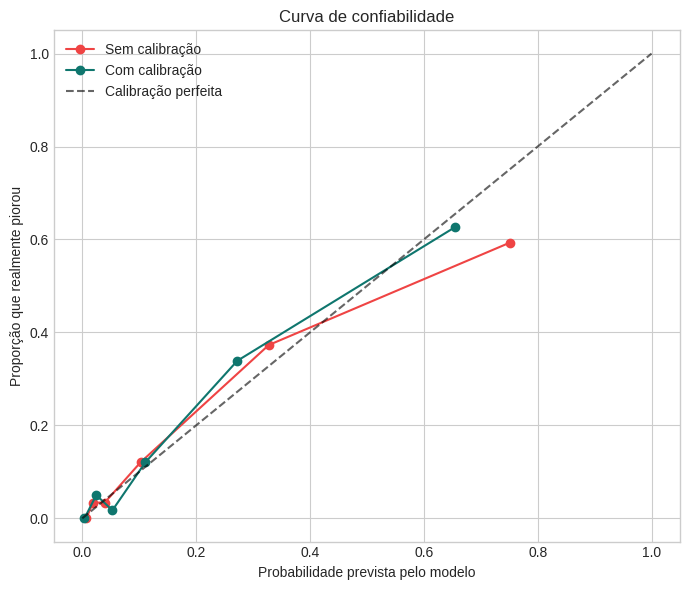


**Como ler:** quanto mais perto da linha tracejada, mais honesto o número. Pontos **acima** da
diagonal = o modelo subestimou o risco; **abaixo** = superestimou.


In [8]:
# Curva de confiabilidade: previsto (eixo X) vs. realidade (eixo Y)
gss_cal = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
i_tr_c, i_te_c = next(gss_cal.split(X, y, grupos))

fig, ax = plt.subplots(figsize=(7, 6))
for label, calibrar, cor in [("Sem calibração", False, "#ef4444"),
                             ("Com calibração", True, "#0f766e")]:
    pipe = constroi_pipeline(clone(gb), calibrar=calibrar)
    pipe.fit(X.iloc[i_tr_c], y.iloc[i_tr_c])
    pr = pipe.predict_proba(X.iloc[i_te_c])[:, 1]
    frac_real, media_prevista = calibration_curve(y.iloc[i_te_c], pr, n_bins=6, strategy="quantile")
    ax.plot(media_prevista, frac_real, marker="o", label=label, color=cor)

ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Calibração perfeita")
ax.set_xlabel("Probabilidade prevista pelo modelo")
ax.set_ylabel("Proporção que realmente piorou")
ax.set_title("Curva de confiabilidade")
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown('''
**Como ler:** quanto mais perto da linha tracejada, mais honesto o número. Pontos **acima** da
diagonal = o modelo subestimou o risco; **abaixo** = superestimou.
'''))


## 9. Treino do modelo final (calibrado)

In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
i_tr, i_te = next(gss.split(X, y, grupos))
X_train, X_test = X.iloc[i_tr], X.iloc[i_te]
y_train, y_test = y.iloc[i_tr], y.iloc[i_te]

modelo_final = constroi_pipeline(candidatos["GradientBoosting"], calibrar=True)
modelo_final.fit(X_train, y_train)
proba_teste = modelo_final.predict_proba(X_test)[:, 1]

display(Markdown(f'''
**Treino:** {len(X_train):,} pares ({y_train.mean()*100:.1f}% positivos) |
**Teste:** {len(X_test):,} pares ({y_test.mean()*100:.1f}% positivos)
**Alunos em comum entre treino e teste:** {len(set(grupos.iloc[i_tr]) & set(grupos.iloc[i_te]))} (deve ser 0)
'''))



**Treino:** 1,012 pares (16.6% positivos) |
**Teste:** 353 pares (19.3% positivos)
**Alunos em comum entre treino e teste:** 0 (deve ser 0)


## 10. Otimização do limiar de decisão

O modelo devolve uma **probabilidade contínua**. Transformá-la em decisão ("sinalizar ou não") exige escolher um corte — e o padrão de 0,50 é uma escolha arbitrária, **inadequada para dado desbalanceado**.

Como só 17,3% dos alunos pioram, o modelo raramente atribui probabilidade acima de 0,50, e o corte padrão acaba sinalizando pouca gente: recall baixo, muitos alunos em risco passando batido. Baixar o limiar aumenta o recall ao custo da precisão.

**Não existe limiar "certo" universal** — ele depende da capacidade de atendimento da equipe. Por isso apresentamos a curva completa e salvamos o limiar escolhido junto do modelo.


,Limiar,Recall,Precisão,F1,% alunos sinalizados
0,0.10,0.897,0.412,0.565,41.9%
1,0.15,0.838,0.456,0.591,35.4%
2,0.20,0.809,0.505,0.621,30.9%
3,0.25,0.706,0.545,0.615,24.9%
4,0.30,0.632,0.566,0.597,21.5%
5,0.35,0.618,0.592,0.604,20.1%
6,0.40,0.588,0.615,0.602,18.4%
7,0.45,0.529,0.643,0.581,15.9%
8,0.50,0.500,0.667,0.571,14.4%
9,0.55,0.471,0.744,0.577,12.2%


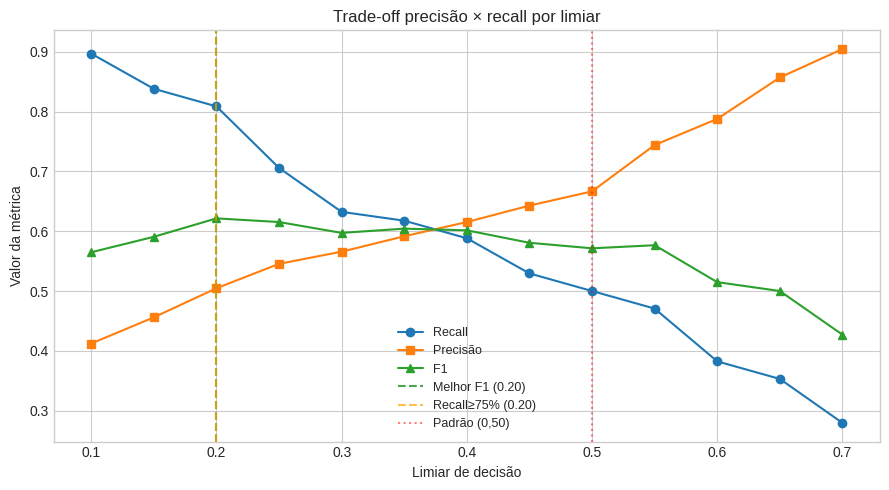


**Limiar escolhido: 0.20** (maximiza F1 — melhor equilíbrio entre não perder alunos em risco e não sobrecarregar a equipe).

Se a Associação tiver capacidade para acompanhar mais alunos, o limiar **0.20** eleva o recall para ≥75%. O limiar é um parâmetro de operação e pode ser alterado no Streamlit sem re-treinar o modelo.


In [10]:
limiares = np.arange(0.10, 0.71, 0.05)
linhas_lim = []
for t in limiares:
    pred = (proba_teste >= t).astype(int)
    linhas_lim.append({
        "Limiar": t,
        "Recall": recall_score(y_test, pred),
        "Precisão": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "% alunos sinalizados": pred.mean() * 100,
    })
curva_limiar = pd.DataFrame(linhas_lim)

LIMIAR_F1 = float(curva_limiar.loc[curva_limiar["F1"].idxmax(), "Limiar"])
recall_alvo = curva_limiar[curva_limiar["Recall"] >= 0.75]
LIMIAR_RECALL75 = float(recall_alvo["Limiar"].max()) if not recall_alvo.empty else np.nan

display(curva_limiar.style.format({
    "Limiar": "{:.2f}", "Recall": "{:.3f}", "Precisão": "{:.3f}",
    "F1": "{:.3f}", "% alunos sinalizados": "{:.1f}%",
}).background_gradient(subset=["F1"], cmap="Greens"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curva_limiar["Limiar"], curva_limiar["Recall"], marker="o", label="Recall")
ax.plot(curva_limiar["Limiar"], curva_limiar["Precisão"], marker="s", label="Precisão")
ax.plot(curva_limiar["Limiar"], curva_limiar["F1"], marker="^", label="F1")
ax.axvline(LIMIAR_F1, color="green", ls="--", alpha=0.7, label=f"Melhor F1 ({LIMIAR_F1:.2f})")
if not np.isnan(LIMIAR_RECALL75):
    ax.axvline(LIMIAR_RECALL75, color="orange", ls="--", alpha=0.7,
               label=f"Recall≥75% ({LIMIAR_RECALL75:.2f})")
ax.axvline(0.5, color="red", ls=":", alpha=0.5, label="Padrão (0,50)")
ax.set_xlabel("Limiar de decisão")
ax.set_ylabel("Valor da métrica")
ax.set_title("Trade-off precisão × recall por limiar")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

LIMIAR_ESCOLHIDO = LIMIAR_F1
display(Markdown(f'''
**Limiar escolhido: {LIMIAR_ESCOLHIDO:.2f}** (maximiza F1 — melhor equilíbrio entre não perder alunos em risco e não sobrecarregar a equipe).

Se a Associação tiver capacidade para acompanhar mais alunos, o limiar **{LIMIAR_RECALL75:.2f}** eleva o recall para ≥75%. O limiar é um parâmetro de operação e pode ser alterado no Streamlit sem re-treinar o modelo.
'''))


## 11. Avaliação do modelo final (no limiar escolhido)

,Modelo final
Acurácia,0.8102
Acur. balanceada,0.8097
Precisão,0.5046
Recall,0.8088
F1,0.6215
ROC-AUC,0.8826
PR-AUC,0.6848
KS,0.6334
Brier,0.0985


                      precision    recall  f1-score   support

         Sem aumento     0.9467    0.8105    0.8733       285
Aumento de defasagem     0.5046    0.8088    0.6215        68

            accuracy                         0.8102       353
           macro avg     0.7257    0.8097    0.7474       353
        weighted avg     0.8616    0.8102    0.8248       353



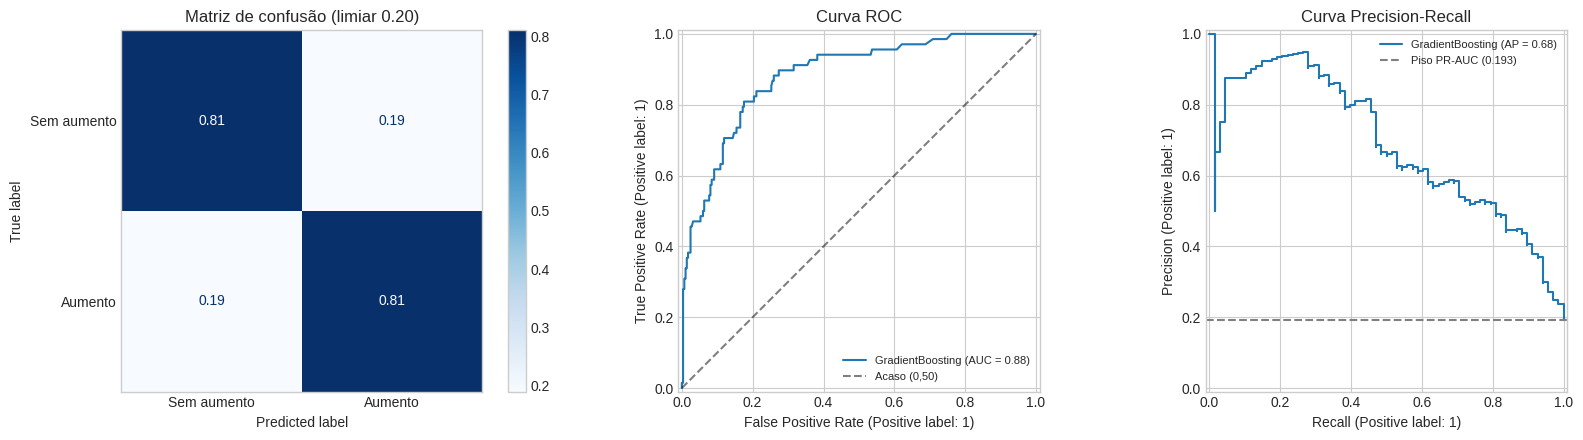

In [11]:
pred_final = (proba_teste >= LIMIAR_ESCOLHIDO).astype(int)

metricas_finais = pd.Series({
    "Acurácia": accuracy_score(y_test, pred_final),
    "Acur. balanceada": balanced_accuracy_score(y_test, pred_final),
    "Precisão": precision_score(y_test, pred_final, zero_division=0),
    "Recall": recall_score(y_test, pred_final),
    "F1": f1_score(y_test, pred_final, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, proba_teste),
    "PR-AUC": average_precision_score(y_test, proba_teste),
    "KS": stats.ks_2samp(proba_teste[y_test == 1], proba_teste[y_test == 0]).statistic,
    "Brier": brier_score_loss(y_test, proba_teste),
}, name="Modelo final")

display(metricas_finais.to_frame().style.format("{:.4f}"))
print(classification_report(y_test, pred_final,
                           target_names=["Sem aumento", "Aumento de defasagem"],
                           digits=4, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_final, display_labels=["Sem aumento", "Aumento"],
    normalize="true", cmap="Blues", values_format=".2f", ax=axes[0])
axes[0].set_title(f"Matriz de confusão (limiar {LIMIAR_ESCOLHIDO:.2f})")
axes[0].grid(False)

RocCurveDisplay.from_predictions(y_test, proba_teste, ax=axes[1], name="GradientBoosting")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Acaso (0,50)")
axes[1].set_title("Curva ROC")
axes[1].legend(fontsize=8)

PrecisionRecallDisplay.from_predictions(y_test, proba_teste, ax=axes[2], name="GradientBoosting")
axes[2].axhline(y_test.mean(), color="gray", ls="--",
                label=f"Piso PR-AUC ({y_test.mean():.3f})")
axes[2].set_title("Curva Precision-Recall")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()


## 12. Importância das variáveis

Importância por permutação: mede quanto o PR-AUC cai ao embaralhar cada variável. Variáveis com valor próximo de zero (ou negativo) não estão contribuindo.


,feature,importancia,desvio
0,defasagem,0.2113,0.0366
1,idade,0.1768,0.0384
2,ipv,0.1192,0.0280
3,ano_ingresso,0.1016,0.0266
4,ida,0.0435,0.0218
5,ips,0.0162,0.0214
6,fase_ordem,0.0115,0.0187
7,pedra,0.0040,0.0081
8,instituicao,0.0038,0.0187
9,ieg,0.0015,0.0147


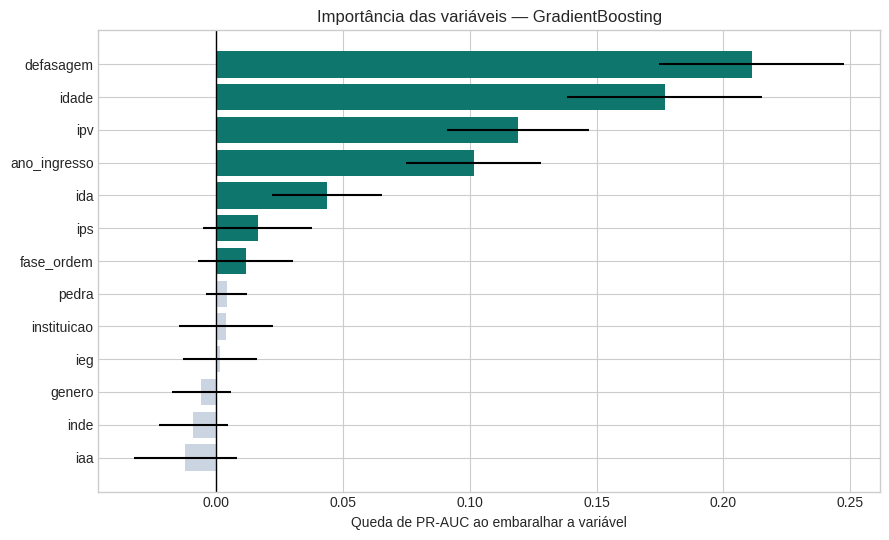

In [12]:
perm = permutation_importance(modelo_final, X_test, y_test,
                              scoring="average_precision", n_repeats=30,
                              random_state=SEED)
importancia = pd.DataFrame({
    "feature": FEATURES,
    "importancia": perm.importances_mean,
    "desvio": perm.importances_std,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

display(importancia.style.format({"importancia": "{:.4f}", "desvio": "{:.4f}"})
        .background_gradient(subset=["importancia"], cmap="Greens"))

fig, ax = plt.subplots(figsize=(9, 5.5))
cores = ["#0f766e" if v > 0.01 else "#cbd5e1" for v in importancia["importancia"]]
ax.barh(importancia["feature"], importancia["importancia"],
        xerr=importancia["desvio"], color=cores)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Queda de PR-AUC ao embaralhar a variável")
ax.set_title("Importância das variáveis — GradientBoosting")
plt.tight_layout()
plt.show()


## 13. Previsão individual e estabilidade

O Streamlit vai consultar o modelo **um aluno por vez**. Esta seção testa esse cenário.

**Um ponto conceitual importante:** não é possível verificar uma probabilidade em um único
aluno — ele piora (1) ou não piora (0), nunca "30%". Por isso a leitura correta é sempre de
frequência:

> *"De cada 100 alunos com perfil parecido com este, cerca de 30 pioram."*

É exatamente isso que a calibração da Seção 8 garante. Abaixo verificamos também **quanta
incerteza** existe em torno de uma previsão individual.


In [13]:
# Previsões individuais: casos de risco alto, baixo e intermediário
Xte_r = X_test.reset_index(drop=True)
yte_r = y_test.reset_index(drop=True)

exemplos_idx = [
    int(np.argmax(proba_teste)),
    int(np.argmin(proba_teste)),
    int(np.argsort(np.abs(proba_teste - 0.30))[0]),
]
linhas_ex = []
for i in exemplos_idx:
    linhas_ex.append({
        "Probabilidade": proba_teste[i],
        "defasagem": Xte_r.loc[i, "defasagem"],
        "idade": Xte_r.loc[i, "idade"],
        "ipv": Xte_r.loc[i, "ipv"],
        "ano_ingresso": Xte_r.loc[i, "ano_ingresso"],
        "Resultado real": "PIOROU" if yte_r[i] == 1 else "não piorou",
    })
display(Markdown("**Exemplos de previsão individual:**"))
display(pd.DataFrame(linhas_ex).style.format({"Probabilidade": "{:.1%}"}))


**Exemplos de previsão individual:**

,Probabilidade,defasagem,idade,ipv,ano_ingresso,Resultado real
0,100.0%,0,9,6.278000,2020,PIOROU
1,0.0%,-1,10,8.836667,2023,não piorou
2,29.5%,0,8,9.670000,2023,PIOROU


In [14]:
# Estabilidade: mesmo aluno, modelo treinado com 5 divisões diferentes
aluno_teste = Xte_r.iloc[[exemplos_idx[2]]]
probas_aluno = []
for s in range(5):
    pipe_s = constroi_pipeline(clone(candidatos["GradientBoosting"]), calibrar=True)
    gss_s = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=s)
    i_tr_s, _ = next(gss_s.split(X, y, grupos))
    pipe_s.fit(X.iloc[i_tr_s], y.iloc[i_tr_s])
    probas_aluno.append(pipe_s.predict_proba(aluno_teste)[:, 1][0])

probas_aluno = np.array(probas_aluno)
display(Markdown(f'''
**Mesmo aluno, 5 modelos treinados em divisões diferentes:**
{", ".join(f"{p:.1%}" for p in probas_aluno)}

Média **{probas_aluno.mean():.1%}**, variando de {probas_aluno.min():.1%} a {probas_aluno.max():.1%}
(amplitude de {probas_aluno.max()-probas_aluno.min():.1%}).

**Implicação para a interface:** a probabilidade individual é uma **estimativa**, não um valor
exato — consequência natural de uma base com {len(X):,} registros. Exibir "29,4%" sugere uma
precisão que não existe. Por isso o Streamlit deve mostrar **faixas de risco**, não o número
cru com casas decimais.
'''))



**Mesmo aluno, 5 modelos treinados em divisões diferentes:**
85.7%, 66.4%, 69.3%, 61.2%, 64.8%

Média **69.5%**, variando de 61.2% a 85.7%
(amplitude de 24.5%).

**Implicação para a interface:** a probabilidade individual é uma **estimativa**, não um valor
exato — consequência natural de uma base com 1,365 registros. Exibir "29,4%" sugere uma
precisão que não existe. Por isso o Streamlit deve mostrar **faixas de risco**, não o número
cru com casas decimais.


In [15]:
# Faixas de risco para a interface
FAIXAS_RISCO = [
    ("Baixo", 0.00, 0.25, "Sem sinal de alerta"),
    ("Médio", 0.25, 0.50, "Monitorar no próximo ciclo"),
    ("Alto", 0.50, 1.01, "Prioridade de acompanhamento"),
]

linhas_faixa = []
for nome, lo, hi, acao in FAIXAS_RISCO:
    m = (proba_teste >= lo) & (proba_teste < hi)
    if m.sum() > 0:
        linhas_faixa.append({
            "Faixa": nome,
            "Intervalo": f"{lo:.0%} – {min(hi,1):.0%}",
            "Alunos": int(m.sum()),
            "% da base": m.mean() * 100,
            "Taxa real de piora": y_test.values[m].mean() * 100,
            "Ação sugerida": acao,
        })

display(Markdown("**Faixas de risco (validadas no conjunto de teste):**"))
display(pd.DataFrame(linhas_faixa).style.format({
    "% da base": "{:.1f}%", "Taxa real de piora": "{:.1f}%"}))

display(Markdown('''
A coluna **"Taxa real de piora"** é a validação da calibração: ela deve crescer de forma
consistente da faixa Baixo para a faixa Alto. É esse número que sustenta a frase mostrada ao
usuário — *"alunos nesta faixa pioram X% das vezes"*.
'''))


**Faixas de risco (validadas no conjunto de teste):**

,Faixa,Intervalo,Alunos,% da base,Taxa real de piora,Ação sugerida
0,Baixo,0% – 25%,265,75.1%,7.5%,Sem sinal de alerta
1,Médio,25% – 50%,37,10.5%,37.8%,Monitorar no próximo ciclo
2,Alto,50% – 100%,51,14.4%,66.7%,Prioridade de acompanhamento



A coluna **"Taxa real de piora"** é a validação da calibração: ela deve crescer de forma
consistente da faixa Baixo para a faixa Alto. É esse número que sustenta a frase mostrada ao
usuário — *"alunos nesta faixa pioram X% das vezes"*.


## 14. Exportação para `.joblib`

In [16]:
MODELO_PATH = Path.cwd() / "modelo_risco_defasagem.joblib"

artefato = {
    "modelo": modelo_final,
    "limiar": LIMIAR_ESCOLHIDO,
    "limiar_recall75": LIMIAR_RECALL75,
    "faixas_risco": FAIXAS_RISCO,
    "features": FEATURES,
    "features_numericas": FEATURES_NUM,
    "features_nominais": FEATURES_NOM,
    "features_ordinais": FEATURES_ORD,
    "ordem_pedra": ORDEM_PEDRA[0],
    "campos_obrigatorios": FEATURES,
    "alvo": "aumento_defasagem: 1 se defasagem(t+1) < defasagem(t)",
    "algoritmo": "GradientBoosting + SMOTE + calibração isotônica",
    "validacao": "GroupShuffleSplit por RA (25% teste)",
    "calibrado": True,
    "metricas_teste": metricas_finais.to_dict(),
    "importancia_features": importancia.to_dict("records"),
    "taxa_positiva_base": float(y.mean()),
    "n_amostras": int(len(X)),
    "data_treino": str(datetime.date.today()),
    "leitura_probabilidade": (
        "Frequência, não certeza individual: 'de cada 100 alunos com perfil "
        "semelhante, cerca de N pioram'. Exibir em faixas, não com decimais."
    ),
}

joblib.dump(artefato, MODELO_PATH)

# Sanity check
recarregado = joblib.load(MODELO_PATH)
proba_check = recarregado["modelo"].predict_proba(X_test)[:, 1]
assert np.abs(proba_check - proba_teste).max() < 1e-9
print(f"Salvo: {MODELO_PATH.name}")
print(f"Sanity check OK — diferença máxima: {np.abs(proba_check - proba_teste).max():.2e}")


Salvo: modelo_risco_defasagem.joblib
Sanity check OK — diferença máxima: 0.00e+00


## 15. Exemplo de uso (prévia do Streamlit)

Cenário real: uma pessoa preenche **todos os 13 campos** no formulário e recebe a probabilidade
de risco daquele aluno.


In [17]:
artefato_carregado = joblib.load(MODELO_PATH)
modelo = artefato_carregado["modelo"]
faixas = artefato_carregado["faixas_risco"]


def classifica_risco(prob):
    for nome, lo, hi, acao in faixas:
        if lo <= prob < hi:
            return nome, acao
    return "Alto", "Prioridade de acompanhamento"


# --- Simulação: um aluno preenchido manualmente no formulário ---
aluno_formulario = pd.DataFrame([{
    "defasagem": -1, "fase_ordem": 3, "idade": 13, "ano_ingresso": 2021,
    "ida": 6.2, "ieg": 5.8, "iaa": 8.0, "ips": 6.5, "ipv": 6.0, "inde": 6.4,
    "genero": "Feminino", "instituicao": "Pública", "pedra": "Ágata",
}])

prob = modelo.predict_proba(aluno_formulario[artefato_carregado["features"]])[:, 1][0]
faixa, acao = classifica_risco(prob)

display(Markdown(f"""
### Resultado para o aluno consultado

| | |
|---|---|
| **Faixa de risco** | **{faixa}** |
| Probabilidade estimada | ~{prob:.0%} |
| Ação sugerida | {acao} |

> *Leitura correta:* de cada 100 alunos com perfil semelhante, cerca de **{prob*100:.0f}**
> aumentam a defasagem no ano seguinte.
"""))

# --- Uso em lote: ranking de prioridade ---
ranking = pv.iloc[i_te][["ra", "defasagem", "idade", "ipv"]].copy()
ranking["probabilidade"] = proba_teste
ranking["faixa"] = [classifica_risco(p)[0] for p in proba_teste]
ranking["piorou_de_fato"] = y_test.values
ranking = ranking.sort_values("probabilidade", ascending=False)

display(Markdown("**Ranking de prioridade (top 10):**"))
display(ranking.head(10).style.format({"probabilidade": "{:.1%}"})
        .background_gradient(subset=["probabilidade"], cmap="Reds"))

display(Markdown(f"""
**Código para o Streamlit:**
```python
art = joblib.load("modelo_risco_defasagem.joblib")

# Os 13 campos são todos obrigatórios no formulário
proba = art["modelo"].predict_proba(df[art["features"]])[:, 1]

# Exibir em faixas, não com decimais
for nome, lo, hi, acao in art["faixas_risco"]:
    ...
```
Todo o pré-processamento (imputação, padronização, encoding) está dentro do pipeline —
o DataFrame de entrada precisa apenas das colunas brutas.
"""))



### Resultado para o aluno consultado

| | |
|---|---|
| **Faixa de risco** | **Baixo** |
| Probabilidade estimada | ~23% |
| Ação sugerida | Sem sinal de alerta |

> *Leitura correta:* de cada 100 alunos com perfil semelhante, cerca de **23**
> aumentam a defasagem no ano seguinte.


**Ranking de prioridade (top 10):**

,ra,defasagem,idade,ipv,probabilidade,faixa,piorou_de_fato
909,RA-638,0,9,6.278000,100.0%,Alto,1
1323,RA-952,0,8,8.425000,93.3%,Alto,0
1342,RA-972,0,8,7.840000,89.7%,Alto,1
1125,RA-782,0,8,7.000000,87.7%,Alto,1
6,RA-1004,0,8,7.420000,86.8%,Alto,1
1319,RA-947,0,8,5.080000,86.8%,Alto,1
46,RA-1057,0,9,8.340000,86.8%,Alto,1
1259,RA-884,0,7,8.660000,86.8%,Alto,1
1225,RA-851,0,8,6.583000,85.7%,Alto,1
894,RA-629,0,9,7.278000,82.4%,Alto,1



**Código para o Streamlit:**
```python
art = joblib.load("modelo_risco_defasagem.joblib")

# Os 13 campos são todos obrigatórios no formulário
proba = art["modelo"].predict_proba(df[art["features"]])[:, 1]

# Exibir em faixas, não com decimais
for nome, lo, hi, acao in art["faixas_risco"]:
    ...
```
Todo o pré-processamento (imputação, padronização, encoding) está dentro do pipeline —
o DataFrame de entrada precisa apenas das colunas brutas.
